## initial definitions

In [173]:
# some preliminary imports, setting up static data etc
from ast import pattern
import nltk
import string
from nltk.corpus import PlaintextCorpusReader
from nltk import FreqDist
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

from enum import Enum

class Corpus(Enum):
    RIU1977 = 0
    RIU1978 = 1
    RIU1987 = 2
    RIU1988 = 3
    RIU1997 = 4
    RIU1998 = 5
    RS1997 = 6

class Decade(Enum):
    Seventies = 0
    Eighties = 1
    Nineties = 2

punctuation_set = set(string.punctuation)

# additional punctuation are pieces of text that I found were appearing in the results 
# that I would like to have been removed with other punctuation
additional_punctuation = set(["'s", "'m", "'", '.', '"', "n't","'ve",
                              '’', '“', '”', '’;', '’’', '.)', '("',
                              '–', '—', '...', '``', "''", '‘', ',"',
                              '•', '”.', '",', '”,', '.):', '":', '’)',
                              '.”', ".'", '’,','’),', '–,', '—,', '’.', 
                              '(‘', '".', ').', '."', "')", '!!', ",'",
                              '")', '"),', '").', '";', '.’', ",’", "’’,",
                              "',", '’).', "-'", '--', '?"',
                              "(“:", "”)", ",”", "'.", ")’", "(“",
                              "?”", "),", "‘‘", "!”", "”),", ").’"])

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

nltk.download('wordnet')
nltk.download('omw-1.4') 

lemmatizer = WordNetLemmatizer()
corpus_root = '.'  # Directory containing text files
file_pattern = r'.*\.txt'  # Pattern to match .txt files
tokenizer = nltk.tokenize.WordPunctTokenizer()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## define scrubbing and other functions

In [174]:
# define a few functions.

def do_scrubbing(tokens: list, remove_punctuation=True, remove_additional_puctuation=True, remove_stopwords=True, lowercase=True, lemmatize=True) -> list:
    # Most of the cleaning out of punctuation, stopwords, plural forms etc, all in one place.
    print("Initial token count:", len(tokens))
    if lowercase:
        tokens = [token.lower() for token in tokens]
    if (remove_punctuation):
        tokens = [word for word in tokens if word not in punctuation_set]
        # tokens = [token.translate(str.maketrans('', '', string.punctuation)) for token in tokens]

    if remove_additional_puctuation:
        tokens = [word for word in tokens if word not in additional_punctuation]

    if remove_stopwords:
        tokens = [word for word in tokens if word not in stop_words]

    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]
    print("Final token count after scrubbing:", len(tokens))
    return tokens

# for analysing the text of the reviews, I prefer to exclude the headers that contain album and artist names, record labels and reviewer names
def remove_header_lines(body: str, pattern: str) -> str:
    lines = body.split('\n')
    reg_exp = re.compile(pattern)
    cleaned_lines = [line for line in lines if not reg_exp.search(line)]
    return '\n'.join(cleaned_lines)

def draw_wordcloud(frequencies: FreqDist, title: str):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(frequencies.most_common(20)))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off") # Turn off the axis labels
    plt.title(title)
    plt.show()

def normalise_frequencies(frequencies: FreqDist, token_count: int) -> FreqDist:
    normalised_frequencies = FreqDist()
    for word, freq in frequencies.items():
        norm_freq = freq / token_count * 100
        normalised_frequencies[word] = norm_freq
    return normalised_frequencies

## load corpora

In [175]:
# now the actual work

corpus = [None] * len(Corpus)
corpus[Corpus.RIU1977.value] = PlaintextCorpusReader('./RIU 70s/', r'RECORDS 77.*\.txt')
corpus[Corpus.RIU1978.value] = PlaintextCorpusReader('./RIU 70s/', r'RECORDS 78.*\.txt')
corpus[Corpus.RIU1987.value] = PlaintextCorpusReader('./RIU 80s/', r'RECORDS 87.*\.txt')
corpus[Corpus.RIU1988.value] = PlaintextCorpusReader('./RIU 80s/', r'RECORDS 88.*\.txt')
corpus[Corpus.RIU1997.value] = PlaintextCorpusReader('./RIU 90s/', r'ALBUMS 97.*\.txt')
corpus[Corpus.RIU1998.value] = PlaintextCorpusReader('./RIU 90s/', r'ALBUMS 98.*\.txt')
corpus[Corpus.RS1997.value] = PlaintextCorpusReader('./RS 90s/', r'RS97.*\.txt')

decade_corpus = [None] * len(Decade)
decade_corpus[Decade.Seventies.value] = PlaintextCorpusReader('./RIU 70s/', r'RECORDS 7[78].*\.txt')
decade_corpus[Decade.Eighties.value] = PlaintextCorpusReader('./RIU 80s/', r'RECORDS 8[78].*\.txt')
decade_corpus[Decade.Nineties.value] = PlaintextCorpusReader('./RIU 90s/', r'ALBUMS 9[789].*\.txt')

raw_review_corpus = [None] * len(Corpus)
review_corpus = [None] * len(Corpus)
review_tokens = [None] * len(Corpus)
scrubbed_tokens = [None] * len(Corpus)
frequencies = [None] * len(Corpus)
normalised_frequencies = [None] * len(Corpus)

decade_raw_review_corpus = [None] * len(Decade)
decade_review_corpus = [None] * len(Decade)
decade_review_tokens = [None] * len(Decade)
decade_scrubbed_tokens = [None] * len(Decade)
decade_frequencies = [None] * len(Decade)
decade_normalised_frequencies = [None] * len(Decade)

# Access the text

# raw_review_corpus[Corpus.RIU1977.value] = corpus[Corpus.RIU1977.value].raw(['RECORDS 77.06.01.txt', 'RECORDS 77.07.01.txt', 'RECORDS 77.08.01.txt', 'RECORDS 77.09.01.txt', 'RECORDS 77.10.01.txt', 'RECORDS 77.11.01.txt', 'RECORDS 77.12.01.txt'])
# raw_review_corpus[Corpus.RIU1978.value] = corpus[Corpus.RIU1978.value].raw(['RECORDS 78.02.01.txt', 'RECORDS 78.07.01.txt', 'RECORDS 78.08.01.txt', 'RECORDS 78.09.01.txt', 'RECORDS 78.10.01.txt', 'RECORDS 78.11.01.txt', 'RECORDS 78.12.01.txt'])
# raw_review_corpus[Corpus.RIU1997.value] = corpus[Corpus.RIU1997.value].raw(['ALBUMS 97.06.01.txt', 'ALBUMS 97.07.01.txt', 'ALBUMS 97.08.01.txt', 'ALBUMS 97.09.01.txt', 'ALBUMS 97.10.01.txt', 'ALBUMS 97.11.01.txt', 'ALBUMS 97.12.01.txt'])
# raw_review_corpus[Corpus.RS1997.value] = corpus[Corpus.RS1997.value].raw(['RS97.07.10.txt', 'RS97.08.07.txt', 'RS97.08.21.txt', 'RS97.09.04.txt', 'RS97.09.18.txt', 'RS97.10.02.txt', 'RS97.10.16.txt'])

# loop through the years to process each corpus
for year in [Corpus.RIU1977.value, Corpus.RIU1978.value, Corpus.RIU1987.value, Corpus.RIU1988.value, Corpus.RIU1997.value, Corpus.RIU1998.value, Corpus.RS1997.value]:
    print('files:', corpus[year].fileids())
    raw_review_corpus[year] = corpus[year].raw(corpus[year].fileids())

    review_corpus[year] = remove_header_lines(raw_review_corpus[year], r'^(Reviewed By:|Artist:|Album:|Record Label:).*$')
    review_tokens[year] = tokenizer.tokenize(review_corpus[year])
    scrubbed_tokens[year] = do_scrubbing(review_tokens[year])
    
print('------------------------------------------------')
for decade in [Decade.Seventies.value, Decade.Eighties.value, Decade.Nineties.value]:
    print('files:', decade_corpus[decade].fileids())
    decade_raw_review_corpus[decade] = decade_corpus[decade].raw(decade_corpus[decade].fileids())

    decade_review_corpus[decade] = remove_header_lines(decade_raw_review_corpus[decade], r'^(Reviewed By:|Artist:|Album:|Record Label:).*$')
    decade_review_tokens[decade] = tokenizer.tokenize(decade_review_corpus[decade])
    decade_scrubbed_tokens[decade] = do_scrubbing(decade_review_tokens[decade])
    
print('------------------------------------------------')

files: ['RECORDS 77.06.01.txt', 'RECORDS 77.07.01.txt', 'RECORDS 77.08.01.txt', 'RECORDS 77.09.01.txt', 'RECORDS 77.10.01.txt', 'RECORDS 77.11.01.txt', 'RECORDS 77.12.01.txt']
Initial token count: 38687
Final token count after scrubbing: 17540
files: ['RECORDS 78.02.01.txt', 'RECORDS 78.03.01.txt', 'RECORDS 78.04.01.txt', 'RECORDS 78.05.01.txt', 'RECORDS 78.06.01.txt', 'RECORDS 78.07.01.txt', 'RECORDS 78.08.01.txt', 'RECORDS 78.09.01.txt', 'RECORDS 78.10.01.txt', 'RECORDS 78.11.01.txt', 'RECORDS 78.12.01.txt']
Initial token count: 60335
Final token count after scrubbing: 27855
files: ['RECORDS 87.07.01.txt', 'RECORDS 87.08.01.txt', 'RECORDS 87.09.01.txt', 'RECORDS 87.10.01.txt', 'RECORDS 87.11.01.txt', 'RECORDS 87.12.01.txt']
Initial token count: 41882
Final token count after scrubbing: 19386
files: ['RECORDS 88.01.01.txt', 'RECORDS 88.02.01.txt']
Initial token count: 14347
Final token count after scrubbing: 6534
files: ['ALBUMS 97.06.01.txt', 'ALBUMS 97.07.01.txt', 'ALBUMS 97.08.01.tx

## corpora stats

In [176]:
from nltk.text import Text
import pandas as pd
raw_review_tokens = [None] * len(Corpus)
headings = ['Year', 'Token Count', 'Review Count', 'Paragraph Count', 'Paragraphs per Review', 'Tokens per Review', 'TTR', 'Reviews per Publication']
data = []
for year in [Corpus.RIU1977.value, Corpus.RIU1978.value, Corpus.RIU1987.value, Corpus.RIU1988.value, Corpus.RIU1997.value, Corpus.RIU1998.value, Corpus.RS1997.value]:
    token_type_count = len(set(scrubbed_tokens[year]))
    token_count = len(scrubbed_tokens[year])
    TTR = token_type_count / token_count
    paragraphs = review_corpus[year].split('\n')
    num_paragraphs = len(paragraphs)
    tokens_per_paragraph = token_count / num_paragraphs
    raw_review_tokens[year] = tokenizer.tokenize(raw_review_corpus[year])
    num_non_reviews = review_tokens[year].count('reviewed')
    num_reviews = raw_review_tokens[year].count('Reviewed') - num_non_reviews
    paragraphs_per_review = num_paragraphs / num_reviews
    tokens_per_review = token_count / num_reviews
    reviews_per_publication = num_reviews / len(corpus[year].fileids())
    data.append([year, token_count, num_reviews, num_paragraphs, paragraphs_per_review, tokens_per_review, TTR, reviews_per_publication ])

df = pd.DataFrame(data, columns=headings )
print(df)
raw_review_tokens = [None] * len(Decade)
headings = ['Decade', 'Token Count', 'Review Count', 'Paragraph Count', 'Paragraphs per Review', 'Tokens per Review', 'TTR', 'Reviews per Publication']
data = []
for decade in [Decade.Seventies.value, Decade.Eighties.value, Decade.Nineties.value]:
    token_type_count = len(set(decade_scrubbed_tokens[decade]))
    token_count = len(decade_scrubbed_tokens[decade])
    TTR = token_type_count / token_count
    paragraphs = decade_review_corpus[decade].split('\n')
    num_paragraphs = len(paragraphs)
    tokens_per_paragraph = token_count / num_paragraphs
    raw_review_tokens[decade] = tokenizer.tokenize(decade_raw_review_corpus[decade])
    num_non_reviews = decade_review_tokens[decade].count('reviewed')
    num_reviews = raw_review_tokens[decade].count('Reviewed') - num_non_reviews
    paragraphs_per_review = num_paragraphs / num_reviews
    tokens_per_review = token_count / num_reviews
    reviews_per_publication = num_reviews / len(decade_corpus[decade].fileids())
    data.append([decade, token_count, num_reviews, num_paragraphs, paragraphs_per_review, tokens_per_review, TTR, reviews_per_publication ])
df = pd.DataFrame(data, columns=headings )
print(df)

   Year  Token Count  Review Count  Paragraph Count  Paragraphs per Review  \
0     0        17540            83              592               7.132530   
1     1        27855           161             1023               6.354037   
2     2        19386           147              492               3.346939   
3     3         6534            42              177               4.214286   
4     4        25665           233              511               2.193133   
5     5        13012           121              285               2.355372   
6     6        18758           105              319               3.038095   

   Tokens per Review       TTR  Reviews per Publication  
0         211.325301  0.297263                11.857143  
1         173.012422  0.259523                14.636364  
2         131.877551  0.316414                24.500000  
3         155.571429  0.461126                21.000000  
4         110.150215  0.300721                33.285714  
5         107.537190  0.394

## frequency distributions of tokens

In [177]:

for year in [Corpus.RIU1977.value, Corpus.RIU1978.value, Corpus.RIU1987.value, Corpus.RIU1988.value, Corpus.RIU1997.value, Corpus.RIU1998.value, Corpus.RS1997.value]:
    frequencies[year] = FreqDist(scrubbed_tokens[year])
    token_count = len(scrubbed_tokens[year])
    # print(f"Most common words in {Year(year).name} (absolute frequencies):")
        # for word, freq in frequencies[year].most_common(20):
        #     print(f"  {word}: {freq}")
    # normalising becomes important when comparing corpora of different sizes
    # print(f"Most common words in {Corpus(year).name} (normalised frequencies):")
    normalised_frequencies[year] = normalise_frequencies(frequencies[year], token_count)
    # for word, freq in normalised_frequencies[year].most_common(20):
    #     print(f"  {word}: {freq:.2}%")
    most_common = frequencies[year].most_common(20)
    # draw_wordcloud(frequencies[year], f"Most common words in {Corpus(year).name}")

for decade in [Decade.Seventies.value, Decade.Eighties.value, Decade.Nineties.value]:
    decade_frequencies[decade] = FreqDist(decade_scrubbed_tokens[decade])
    token_count = len(decade_scrubbed_tokens[decade])
    # print(f"Most common words in {Year(year).name} (absolute frequencies):")
        # for word, freq in frequencies[year].most_common(20):
        #     print(f"  {word}: {freq}")
    # normalising becomes important when comparing corpora of different sizes
    # print(f"Most common words in {Decade(decade).name} (normalised frequencies):")
    decade_normalised_frequencies[decade] = normalise_frequencies(decade_frequencies[decade], token_count)
    for word, freq in decade_normalised_frequencies[decade].most_common(20):
        print(f"  {word}: {freq:.2}%")
    print('------------------------------------------------')
    most_common = decade_frequencies[decade].most_common(20)
    # draw_wordcloud(decade_frequencies[decade], f"Most common words in {Decade(decade).name}")

  album: 1.6%
  song: 1.0%
  one: 0.84%
  like: 0.65%
  band: 0.65%
  record: 0.61%
  new: 0.56%
  rock: 0.52%
  music: 0.48%
  good: 0.44%
  sound: 0.41%
  time: 0.39%
  two: 0.38%
  first: 0.36%
  guitar: 0.35%
  year: 0.33%
  track: 0.33%
  well: 0.31%
  vocal: 0.3%
  little: 0.28%
------------------------------------------------
  album: 1.2%
  like: 1.0%
  song: 0.9%
  one: 0.78%
  track: 0.52%
  sound: 0.52%
  band: 0.49%
  record: 0.46%
  two: 0.43%
  music: 0.43%
  year: 0.43%
  good: 0.39%
  new: 0.37%
  time: 0.37%
  get: 0.36%
  best: 0.35%
  rock: 0.35%
  guitar: 0.34%
  love: 0.32%
  side: 0.31%
------------------------------------------------
  album: 1.3%
  like: 0.78%
  song: 0.67%
  sound: 0.59%
  track: 0.58%
  band: 0.55%
  one: 0.55%
  rock: 0.47%
  new: 0.4%
  time: 0.35%
  good: 0.35%
  year: 0.33%
  guitar: 0.33%
  get: 0.32%
  vocal: 0.32%
  music: 0.31%
  well: 0.29%
  much: 0.28%
  first: 0.28%
  pop: 0.28%
------------------------------------------------


In [178]:

# more_frequent_in_77 = normalised_frequencies[Corpus.RIU1977.value] - normalised_frequencies[Corpus.RIU1978.value]  # Words more common in first corpus
# more_frequent_in_78 = normalised_frequencies[Corpus.RIU1978.value] - normalised_frequencies[Corpus.RIU1977.value]  # Words more common in second corpus

# for word, freq in more_frequent_in_77.most_common(20):
#     print(f"  {word}: {freq:.1f}%")
# draw_wordcloud(FreqDist(more_frequent_in_77), "Words with Greater Frequency in 1977 Reviews")
# for word, freq in more_frequent_in_78.most_common(20):
#     print(f"  {word}: {freq:.1f}%")
# draw_wordcloud(FreqDist(more_frequent_in_78), "Words with Greater Frequency in 1978 Reviews")


# more_frequent_in_77 = normalised_frequencies[Corpus.RIU1977.value] - normalised_frequencies[Corpus.RIU1997.value]  # Words more common in first corpus
# more_frequent_in_97 = normalised_frequencies[Corpus.RIU1997.value] - normalised_frequencies[Corpus.RIU1977.value]  # Words more common in second corpus

# for word, freq in more_frequent_in_77.most_common(20):
#     print(f"  {word}: {freq:.1f}%")
# draw_wordcloud(FreqDist(more_frequent_in_77), "Words with Greater Frequency in 1977 Reviews")
# for word, freq in more_frequent_in_97.most_common(20):
#     print(f"  {word}: {freq:.1f}%")
# draw_wordcloud(FreqDist(more_frequent_in_97), "Words with Greater Frequency in 1997 Reviews")

# more_frequent_in_70s = normalised_frequencies[Decade.Seventies.value] - normalised_frequencies[Decade.Eighties.value]  # Words more common in first corpus
# more_frequent_in_80s = normalised_frequencies[Decade.Eighties.value] - normalised_frequencies[Decade.Seventies.value]  # Words more common in second corpus

# for word, freq in more_frequent_in_70s.most_common(20):
#     print(f"  {word}: {freq:.1f}%")
# draw_wordcloud(FreqDist(more_frequent_in_70s), "Words with Greater Frequency in 1970s Reviews")
# for word, freq in more_frequent_in_80s.most_common(20):
#     print(f"  {word}: {freq:.1f}%")
# draw_wordcloud(FreqDist(more_frequent_in_80s), "Words with Greater Frequency in 1980s Reviews")

# more_frequent_in_70s = normalised_frequencies[Decade.Seventies.value] - normalised_frequencies[Decade.Nineties.value]  # Words more common in first corpus
# more_frequent_in_90s = normalised_frequencies[Decade.Nineties.value] - normalised_frequencies[Decade.Seventies.value]  # Words more common in second corpus

# for word, freq in more_frequent_in_70s.most_common(20):
#     print(f"  {word}: {freq:.1f}%")
# draw_wordcloud(FreqDist(more_frequent_in_70s), "Words with Greater Frequency in 1970s Reviews (cf. 1990s)")
# for word, freq in more_frequent_in_90s.most_common(20):
#     print(f"  {word}: {freq:.1f}%")
# draw_wordcloud(FreqDist(more_frequent_in_90s), "Words with Greater Frequency in 1990s Reviews (cf. 1970s)")

# more_frequent_in_80s = normalised_frequencies[Decade.Eighties.value] - normalised_frequencies[Decade.Nineties.value]  # Words more common in first corpus
# more_frequent_in_90s = normalised_frequencies[Decade.Nineties.value] - normalised_frequencies[Decade.Eighties.value]  # Words more common in second corpus

# for word, freq in more_frequent_in_80s.most_common(20):
#     print(f"  {word}: {freq:.1f}%")
# draw_wordcloud(FreqDist(more_frequent_in_80s), "Words with Greater Frequency in 1980s Reviews")
# for word, freq in more_frequent_in_90s.most_common(20):
#     print(f"  {word}: {freq:.1f}%")
# draw_wordcloud(FreqDist(more_frequent_in_90s), "Words with Greater Frequency in 1990s Reviews")



## log likelihood functions

In [179]:
import math

from shapely import reverse

def calculate_single_log_likelihood(a: int, b: int, c: int, d: int):
    E1 = c * (a + b) / (c + d)
    E2 = d * (a + b) / (c + d)
    G_squared = 2*((a * math.log(a / E1) if a != 0 else 0) + (b * math.log(b / E2) if b != 0 else 0))
    return G_squared


def calculate_log_likelihoods(freq_1: FreqDist, word_count_1: int, freq_2: FreqDist, word_count_2: int):
    all_words = set(freq_1.keys()).union(set(freq_2.keys()))
    ll_scores = {}
    for word in all_words:
        # if (freq_1[word] > 10) | (freq_2[word] > 10):
        a = freq_1[word]
        b = freq_2[word]
        c = word_count_1
        d = word_count_2
        ll_scores[word] = calculate_single_log_likelihood(a, b, c, d)
    return ll_scores


## calculate log likelihoods of token differences

In [180]:
# CELL: Refactored Log Likelihood Analysis Functions
# Common functions for analyzing log likelihood differences between decades
# Works with both token frequencies and bigram frequencies

def analyze_decade_log_likelihoods(frequency_dicts, scrubbed_tokens_list, analysis_type="tokens", 
                                   significance_thresholds={"7_9": 30, "7_8": 15, "8_9": 15}):
    """
    Analyze log likelihood differences between decades for tokens or bigrams.
    
    Args:
        frequency_dicts: List of FreqDist objects (one per decade)
        scrubbed_tokens_list: List of token lists (for calculating corpus sizes)
        analysis_type: "tokens" or "bigrams" for labeling output
        significance_thresholds: Dict with threshold values for each decade comparison
    
    Returns:
        Dict containing:
        - 'LLs_7_8', 'LLs_8_9', 'LLs_7_9': Log likelihood dictionaries
        - 'significantly_changed': Set of significantly changed items
        - 'increased_use_7_8', 'increased_use_8_9': Lists of items with increased use
    """
    
    # Initialize storage for results
    increased_use_7_8 = [[], [], []]
    increased_use_8_9 = [[], [], []]
    
    # Calculate log likelihoods for all decade pairs
    LLs_7_8 = calculate_log_likelihoods(
        frequency_dicts[Decade.Seventies.value], len(scrubbed_tokens_list[Decade.Seventies.value]),
        frequency_dicts[Decade.Eighties.value], len(scrubbed_tokens_list[Decade.Eighties.value])
    )
    LLs_8_9 = calculate_log_likelihoods(
        frequency_dicts[Decade.Eighties.value], len(scrubbed_tokens_list[Decade.Eighties.value]),
        frequency_dicts[Decade.Nineties.value], len(scrubbed_tokens_list[Decade.Nineties.value])
    )
    LLs_7_9 = calculate_log_likelihoods(
        frequency_dicts[Decade.Seventies.value], len(scrubbed_tokens_list[Decade.Seventies.value]),
        frequency_dicts[Decade.Nineties.value], len(scrubbed_tokens_list[Decade.Nineties.value])
    )
    
    # Sort results
    sorted_LLs_7_8 = sorted(LLs_7_8.items(), key=lambda x: x[1], reverse=True)
    sorted_LLs_8_9 = sorted(LLs_8_9.items(), key=lambda x: x[1], reverse=True)
    sorted_LLs_7_9 = sorted(LLs_7_9.items(), key=lambda x: x[1], reverse=True)
    
    # Analyze 70s vs 90s changes
    print(f"{analysis_type.title()} with significantly changed use by Log-Likelihood scores:")
    significantly_changed = set()
    
    significance_threshold = significance_thresholds["7_9"]
    for item, score in sorted_LLs_7_9:
        if score > significance_threshold:
            print(f"  {item}: {score:.2f}. From {frequency_dicts[Decade.Seventies.value][item]} to {frequency_dicts[Decade.Nineties.value][item]} appearances.")
            significantly_changed.add(item)
    print(f"Total of {len(significantly_changed)} {analysis_type} with significantly changed use between 1970s and 1990s reviews.")
    
    # Analyze 70s vs 80s changes
    significance_threshold = significance_thresholds["7_8"]
    print(f"\n{analysis_type.title()} with significantly changed use by Log-Likelihood scores:")
    for item, score in sorted_LLs_7_8:
        if score > significance_threshold:
            significantly_changed.add(item)
            print(f"  {item}: {score:.2f}. From {frequency_dicts[Decade.Seventies.value][item]} to {frequency_dicts[Decade.Eighties.value][item]} appearances.")
            
            # Determine which decade had higher frequency
            if analysis_type == "tokens":
                # For tokens, use normalized frequencies for comparison
                if decade_normalised_frequencies[Decade.Seventies.value][item] > decade_normalised_frequencies[Decade.Eighties.value][item]:
                    increased_use_7_8[Decade.Seventies.value].append((item, score))
                else:
                    increased_use_7_8[Decade.Eighties.value].append((item, score))
            else:
                # For bigrams, use raw frequencies for comparison
                if frequency_dicts[Decade.Seventies.value][item] > frequency_dicts[Decade.Eighties.value][item]:
                    increased_use_7_8[Decade.Seventies.value].append((item, score))
                else:
                    increased_use_7_8[Decade.Eighties.value].append((item, score))
    
    print(f"{len(increased_use_7_8[Decade.Seventies.value])} + {len(increased_use_7_8[Decade.Eighties.value])} {analysis_type.title()} with significantly changed use between 1970s and 1980s reviews.")
    
    # Analyze 80s vs 90s changes
    significance_threshold = significance_thresholds["8_9"]
    print(f"\n{analysis_type.title()} with significantly changed use by Log-Likelihood scores:")
    for item, score in sorted_LLs_8_9:
        if score > significance_threshold:
            significantly_changed.add(item)
            if frequency_dicts[Decade.Eighties.value][item] > frequency_dicts[Decade.Nineties.value][item]:
                print(f">  {item}: {score:.2f}. From {frequency_dicts[Decade.Eighties.value][item]} to {frequency_dicts[Decade.Nineties.value][item]} appearances.")
                increased_use_8_9[Decade.Eighties.value].append((item, score))
            else:
                print(f"<  {item}: {score:.2f}. From {frequency_dicts[Decade.Eighties.value][item]} to {frequency_dicts[Decade.Nineties.value][item]} appearances.")
                increased_use_8_9[Decade.Nineties.value].append((item, score))
    
    print(f"{len(increased_use_8_9[Decade.Eighties.value])} + {len(increased_use_8_9[Decade.Nineties.value])} {analysis_type.title()} with significantly changed use between 1980s and 1990s reviews.")
    
    return {
        'LLs_7_8': LLs_7_8,
        'LLs_8_9': LLs_8_9,
        'LLs_7_9': LLs_7_9,
        'significantly_changed': significantly_changed,
        'increased_use_7_8': increased_use_7_8,
        'increased_use_8_9': increased_use_8_9
    }

def draw_analysis_wordclouds(increased_use_7_8, increased_use_8_9, analysis_type="tokens"):
    """
    Draw wordclouds for significantly changed items between decades.
    
    Args:
        increased_use_7_8: List of items with increased use between 70s and 80s
        increased_use_8_9: List of items with increased use between 80s and 90s
        analysis_type: "tokens" or "bigrams" for labeling
    """
    # Draw wordclouds for 70s vs 80s
    for decade in [Decade.Seventies.value, Decade.Eighties.value]:
        if analysis_type == "tokens":
            freq_dist = FreqDist(dict(increased_use_7_8[decade]))
        else:
            freq_dist = FreqDist(dict(increased_use_7_8[decade]))
        
        draw_wordcloud(freq_dist, f"{analysis_type.title()} with Significantly Increased Use in " + Decade(decade).name + " Reviews")
    
    # Draw wordclouds for 80s vs 90s
    for decade in [Decade.Eighties.value, Decade.Nineties.value]:
        if analysis_type == "tokens":
            freq_dist = FreqDist(dict(increased_use_8_9[decade]))
        else:
            freq_dist = FreqDist(dict(increased_use_8_9[decade]))
        
        draw_wordcloud(freq_dist, f"{analysis_type.title()} with Significantly Increased Use in " + Decade(decade).name + " Reviews")

Tokens with significantly changed use by Log-Likelihood scores:
  record: 87.95. From 276 to 78 appearances.
  group: 85.14. From 106 to 8 appearances.
  hop: 72.06. From 1 to 52 appearances.
  sample: 49.71. From 3 to 44 appearances.
  dj: 49.69. From 0 to 32 appearances.
  arrangement: 41.84. From 73 to 11 appearances.
  hip: 41.60. From 4 to 41 appearances.
  dub: 38.98. From 1 to 30 appearances.
  80: 35.51. From 2 to 31 appearances.
  noise: 34.83. From 4 to 36 appearances.
  however: 34.42. From 70 to 13 appearances.
  song: 33.35. From 470 to 258 appearances.
  hardcore: 32.61. From 0 to 21 appearances.
  label: 32.23. From 15 to 56 appearances.
  newman: 32.05. From 26 to 0 appearances.
  ronstadt: 32.05. From 26 to 0 appearances.
  beat: 31.48. From 24 to 70 appearances.
  compilation: 31.33. From 11 to 48 appearances.
  disc: 31.13. From 9 to 44 appearances.
  reed: 30.86. From 31 to 1 appearances.
Total of 20 tokens with significantly changed use between 1970s and 1990s revi

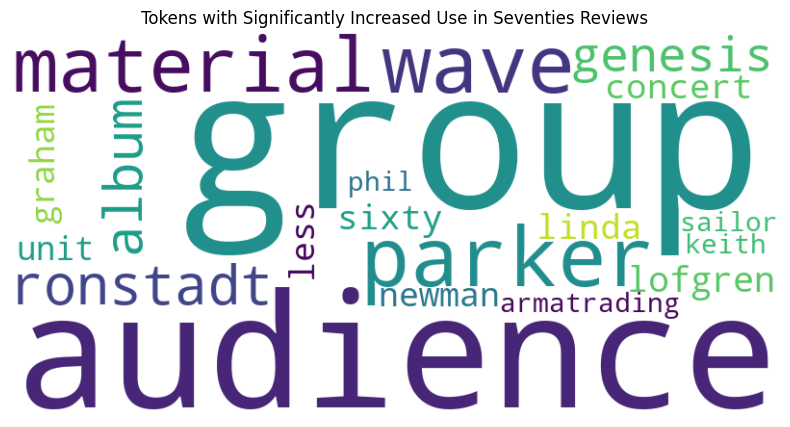

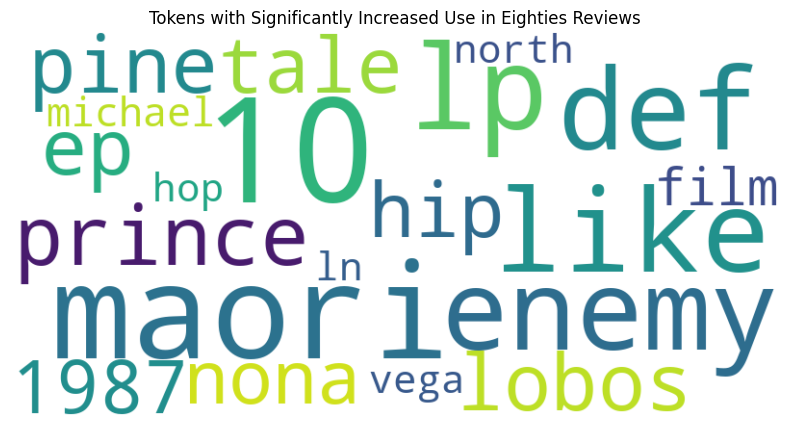

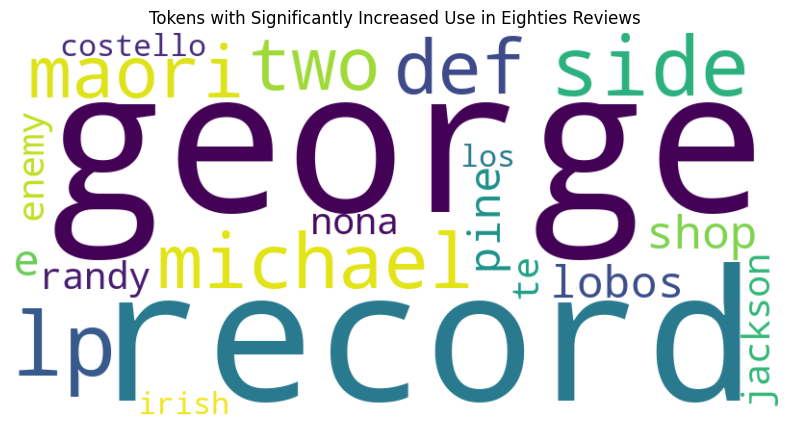

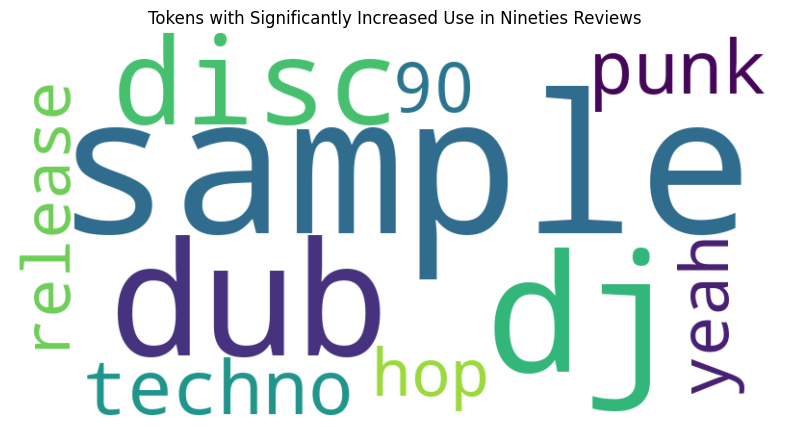

Word with significantly changed use by Log-Likelihood scores:
  record: 117.39. From 276 to 78 appearances.
  group: 100.10. From 106 to 8 appearances.
  hop: 63.55. From 1 to 52 appearances.
  song: 62.64. From 470 to 258 appearances.
  arrangement: 51.23. From 73 to 11 appearances.
  one: 49.51. From 381 to 211 appearances.
  dj: 44.36. From 0 to 32 appearances.
  however: 43.01. From 70 to 13 appearances.
  sample: 42.84. From 3 to 44 appearances.
  newman: 36.04. From 26 to 0 appearances.
  ronstadt: 36.04. From 26 to 0 appearances.
  reed: 35.46. From 31 to 1 appearances.
  hip: 35.39. From 4 to 41 appearances.
  album: 34.77. From 729 to 521 appearances.
  disco: 34.46. From 43 to 5 appearances.
  dub: 34.14. From 1 to 30 appearances.
  musician: 33.91. From 59 to 12 appearances.
  cooder: 33.27. From 24 to 0 appearances.
  parker: 32.82. From 29 to 1 appearances.
  genesis: 31.88. From 23 to 0 appearances.
  80: 30.66. From 2 to 31 appearances.
  work: 30.55. From 115 to 46 appe

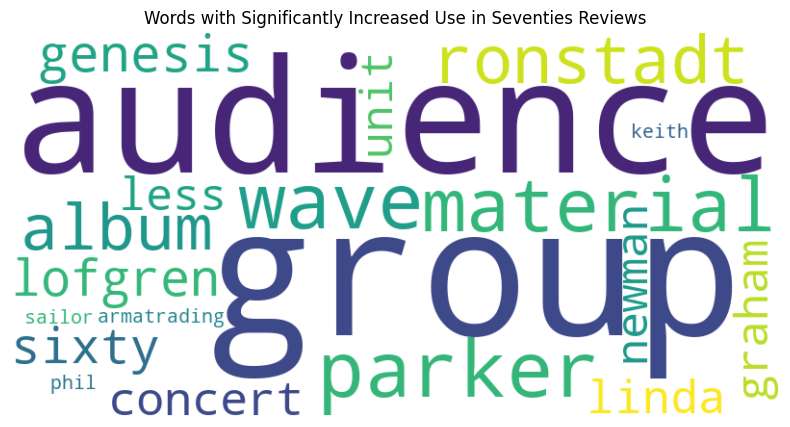

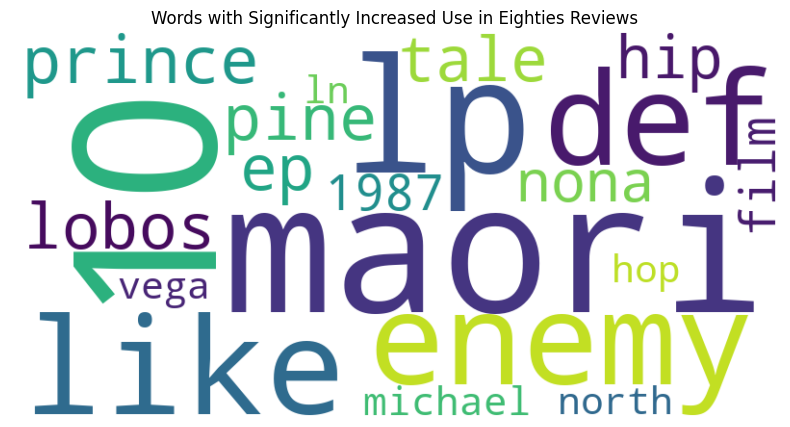

Word with significantly changed use by Log-Likelihood scores:
>  george: 40.18. From 29 to 2 appearances.
<  sample: 37.37. From 1 to 44 appearances.
>  record: 32.84. From 119 to 78 appearances.
>  lp: 31.78. From 24 to 2 appearances.
>  side: 27.91. From 80 to 46 appearances.
<  dj: 25.69. From 1 to 32 appearances.
<  dub: 23.77. From 1 to 30 appearances.
>  michael: 23.34. From 21 to 3 appearances.
<  disc: 21.97. From 5 to 44 appearances.
>  def: 21.92. From 12 to 0 appearances.
>  two: 21.07. From 112 to 87 appearances.
>  maori: 20.31. From 17 to 2 appearances.
<  techno: 19.49. From 0 to 19 appearances.
>  shop: 19.25. From 14 to 1 appearances.
<  punk: 19.05. From 11 to 58 appearances.
>  e: 18.71. From 16 to 2 appearances.
>  lobos: 18.26. From 10 to 0 appearances.
>  pine: 18.26. From 10 to 0 appearances.
<  90: 16.80. From 2 to 27 appearances.
>  randy: 16.44. From 9 to 0 appearances.
>  nona: 16.44. From 9 to 0 appearances.
>  te: 16.44. From 9 to 0 appearances.
>  jackson:

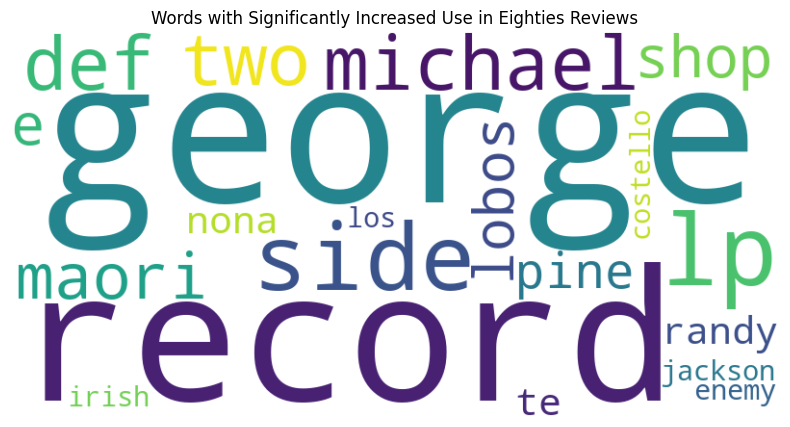

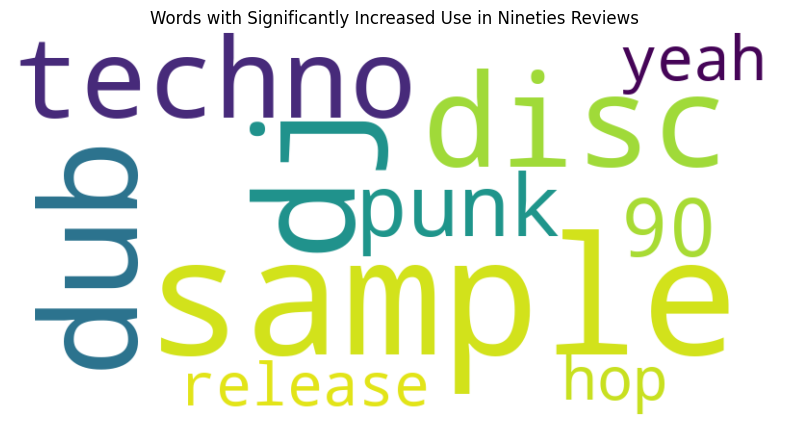

In [181]:

# CELL: Token Log Likelihood Analysis (using refactored functions)
# Using the common functions to analyze token frequency differences

# Use the refactored function for token analysis
token_results = analyze_decade_log_likelihoods(
    frequency_dicts=decade_frequencies,
    scrubbed_tokens_list=decade_scrubbed_tokens,
    analysis_type="tokens",
    significance_thresholds={"7_9": 30, "7_8": 15, "8_9": 15}
)

# Extract results for compatibility with existing code
LLs_7_8 = token_results['LLs_7_8']
LLs_8_9 = token_results['LLs_8_9'] 
LLs_7_9 = token_results['LLs_7_9']
significantly_changed = token_results['significantly_changed']
increased_use_7_8 = token_results['increased_use_7_8']
increased_use_8_9 = token_results['increased_use_8_9']

# Draw wordclouds
draw_analysis_wordclouds(increased_use_7_8, increased_use_8_9, "tokens")
#     all_words = set(freq_1.keys()).union(set(freq_2.keys()))
#     ll_scores = {}
#     for word in all_words:
#         # if (freq_1[word] > 10) | (freq_2[word] > 10):
#         a = freq_1[word]
#         b = freq_2[word]
#         c = word_count_1
#         d = word_count_2
#         ll_scores[word] = calculate_single_log_likelihood(a, b, c, d) * (a+b)/(c+d) * 100
#     print(f"Calculated adjusted log-likelihoods for {len(ll_scores)} words.")
#     print(f"Top 10 words by adjusted log-likelihood:")
#     sorted_lls = sorted(ll_scores.items(), key=lambda x: x[1], reverse=True)
#     for word, score in sorted_lls[:10]:
#         print(f"  {word}: {score:.2f}")
#     return ll_scores

increased_use_7_8 = [[], [], []]
increased_use_8_9 = [[], [], []]

# note: back to using raw frequencies rather than normalised ones.
LLs_7_8 = calculate_log_likelihoods(decade_frequencies[Decade.Seventies.value], len(decade_scrubbed_tokens[Decade.Seventies.value]), decade_frequencies[Decade.Eighties.value], len(decade_scrubbed_tokens[Decade.Eighties.value]))
LLs_8_9 = calculate_log_likelihoods(decade_frequencies[Decade.Eighties.value], len(decade_scrubbed_tokens[Decade.Eighties.value]), decade_frequencies[Decade.Nineties.value], len(decade_scrubbed_tokens[Decade.Nineties.value]))
LLs_7_9 = calculate_log_likelihoods(decade_frequencies[Decade.Seventies.value], len(decade_scrubbed_tokens[Decade.Nineties.value]), decade_frequencies[Decade.Nineties.value], len(decade_scrubbed_tokens[Decade.Nineties.value]))
sorted_LLs_7_8 = sorted(LLs_7_8.items(), key=lambda x: x[1], reverse=True)
sorted_LLs_8_9 = sorted(LLs_8_9.items(), key=lambda x: x[1], reverse=True)
sorted_LLs_7_9 = sorted(LLs_7_9.items(), key=lambda x: x[1], reverse=True)
print("Word with significantly changed use by Log-Likelihood scores:")
significance_threshold = 6.63  # p < 0.01
significance_threshold = 30
significantly_changed = set()
for word, score in sorted_LLs_7_9:
    if (score > significance_threshold): # LL scores greater than 6.63 are considered highly significant
        print(f"  {word}: {score:.2f}. From {decade_frequencies[Decade.Seventies.value][word]} to {decade_frequencies[Decade.Nineties.value][word]} appearances.")
        significantly_changed.add(word)
print(f"Total of {len(significantly_changed)} words with significantly changed use between 1970s and 1990s reviews.")

significance_threshold = 15

print("Word with significantly changed use by Log-Likelihood scores:")
for word, score in sorted_LLs_7_8:
    if (score > significance_threshold): # LL scores greater than 6.63 are considered highly significant
        significantly_changed.add(word)
        print(f"  {word}: {score:.2f}. From {decade_frequencies[Decade.Seventies.value][word]} to {decade_frequencies[Decade.Eighties.value][word]} appearances.")
        if (decade_normalised_frequencies[Decade.Seventies.value][word] > decade_normalised_frequencies[Decade.Eighties.value][word]):
            increased_use_7_8[Decade.Seventies.value].append((word, score))
        else:
            increased_use_7_8[Decade.Eighties.value].append((word, score))
print(f"{len(increased_use_7_8[Decade.Seventies.value])} + {len(increased_use_7_8[Decade.Eighties.value])} Words with significantly changed use between 1970s and 1980s reviews.")

for decade in [Decade.Seventies.value, Decade.Eighties.value]:
    word_freq_dist = FreqDist(dict(increased_use_7_8[decade]))

    draw_wordcloud(word_freq_dist, "Words with Significantly Increased Use in " + Decade(decade).name + " Reviews")

print("Word with significantly changed use by Log-Likelihood scores:")
for word, score in sorted_LLs_8_9:
    if (score > significance_threshold): # LL scores greater than 6.63 are considered highly significant
        significantly_changed.add(word)
        if (decade_normalised_frequencies[Decade.Eighties.value][word] > decade_normalised_frequencies[Decade.Nineties.value][word]):
            print(f">  {word}: {score:.2f}. From {decade_frequencies[Decade.Eighties.value][word]} to {decade_frequencies[Decade.Nineties.value][word]} appearances.")
            increased_use_8_9[Decade.Eighties.value].append((word, score))
        else:
            print(f"<  {word}: {score:.2f}. From {decade_frequencies[Decade.Eighties.value][word]} to {decade_frequencies[Decade.Nineties.value][word]} appearances.")
            increased_use_8_9[Decade.Nineties.value].append((word, score))
print(f"{len(increased_use_8_9[Decade.Eighties.value])} + {len(increased_use_8_9[Decade.Nineties.value])} Words with significantly changed use between 1980s and 1990s reviews.")

for decade in [Decade.Eighties.value, Decade.Nineties.value]:
    word_freq_dist = FreqDist(dict(increased_use_8_9[decade]))

    draw_wordcloud(word_freq_dist, "Words with Significantly Increased Use in " + Decade(decade).name + " Reviews")



## show changes as a "slopegraph"

26 {'like', 'guitar', 'album', 'best', 'much', 'first', 'side', 'song', 'well', 'vocal', 'time', 'record', 'pop', 'band', 'year', 'little', 'sound', 'one', 'two', 'love', 'rock', 'good', 'track', 'new', 'music', 'get'}


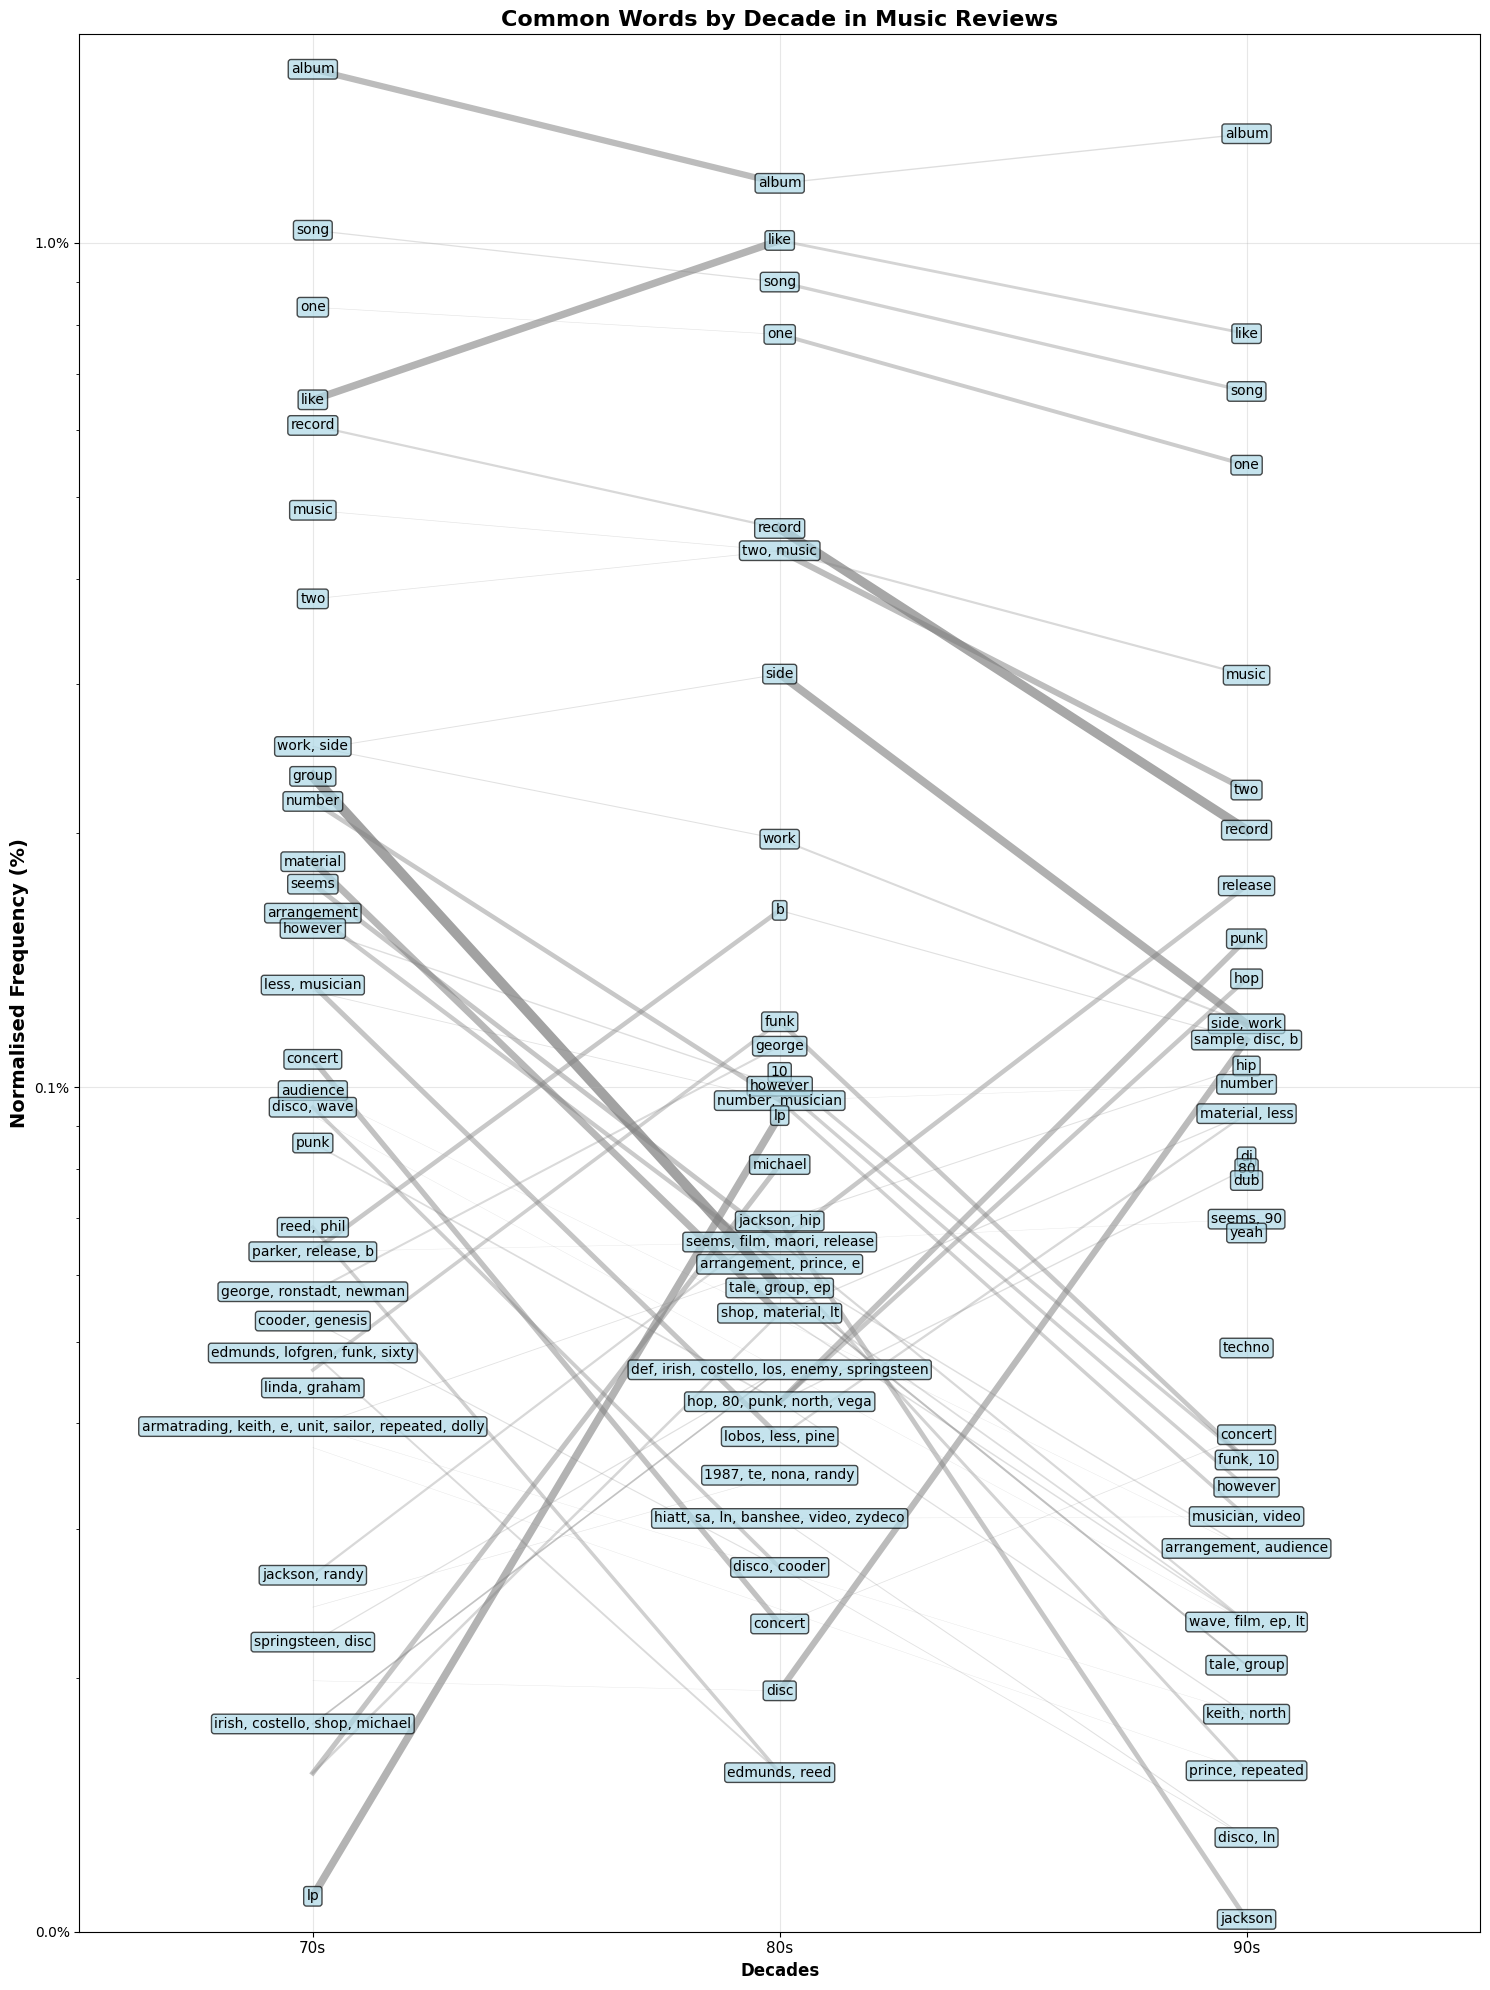

In [182]:
plt.figure(figsize=(15, 20))

decade_names = ['70s', '80s', '90s']
decade_indices = [Decade.Seventies.value, Decade.Eighties.value, Decade.Nineties.value]

# Find the maximum frequency across all decades for setting y-axis limit
max_freq = 0
min_freq = float('inf')  # Track minimum frequency for log scale
most_common_set = set()

for i, decade in enumerate(decade_indices):
    most_common_words = decade_normalised_frequencies[decade].most_common(20)
    for pair in most_common_words:
        most_common_set.add(pair[0])
print(len(most_common_set), most_common_set)

# Get the 20 most common words for each decade and plot them
word_positions = {}  # Store positions of each word across decades

for i, decade in enumerate(decade_indices):
    decade_frequencies[decade] = FreqDist(decade_scrubbed_tokens[decade])
    token_count = len(decade_scrubbed_tokens[decade])
    decade_normalised_frequencies[decade] = normalise_frequencies(decade_frequencies[decade], token_count)
    
    # Instead of getting just the top 20 for this decade, get frequencies for all words in most_common_set
    decade_word_freqs = []
    for word in significantly_changed:
    # for word in most_common_set:
        freq = decade_normalised_frequencies[decade][word]  # This will be 0 if word not in this decade
        if freq > 0.01:  # Only include words with frequency > 0.01% to avoid log scale issues
            decade_word_freqs.append((word, freq))
    
    # Sort by frequency for this decade
    decade_word_freqs.sort(key=lambda x: x[1], reverse=True)
    
    # Update maximum and minimum frequency
    if decade_word_freqs:
        max_freq = max(max_freq, decade_word_freqs[0][1] *1000)
        min_freq = min(min_freq, decade_word_freqs[-1][1] *1000)  # Track minimum frequency
    
    # Plot each word as text at its frequency position
    # Move columns in from sides: use positions 0.7, 1.5, 2.3 instead of 0, 1, 2
    x_pos = 0.7 + i * 0.8
    
    for j, (word, freq) in enumerate(decade_word_freqs):
        # Store position for line drawing
        if word not in word_positions:
            word_positions[word] = {}
        word_positions[word][i] = (x_pos, freq * 1000)
    
    # Group words with similar frequencies (within threshold)
    frequency_threshold = 0.0025  # Words within 0.01% frequency will be grouped
    grouped_words = {}
    
    for word, freq in decade_word_freqs:
        # Find if there's already a group within threshold
        grouped = False
        for group_freq in grouped_words:
            if abs(freq - group_freq) <= frequency_threshold:
                grouped_words[group_freq].append(word)
                grouped = True
                break
        
        if not grouped:
            grouped_words[freq] = [word]
    
    # Plot grouped words
    for group_freq, words in grouped_words.items():
        if len(words) == 1:
            # Single word - plot normally
            word = words[0]
            plt.text(x_pos, group_freq * 1000, word, 
                    ha='center', va='center', 
                    fontsize=10, 
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='lightblue', alpha=0.7))
        else:
            # Multiple words - combine in single box
            combined_text = ', '.join(words)
            plt.text(x_pos, group_freq * 1000, combined_text, 
                    ha='center', va='center', 
                    fontsize=10,  # Slightly smaller font for grouped words
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='lightblue', alpha=0.7))

# Draw lines connecting the same words across decades with thickness proportional to LL scores
for word, positions in word_positions.items():
    if len(positions) > 1:  # Only draw lines for words that appear in multiple decades
        # Sort positions by decade index
        sorted_positions = sorted(positions.items())
        
        # Draw line segments between consecutive decades with LL-based thickness
        for i in range(len(sorted_positions) - 1):
            current_decade = sorted_positions[i][0]
            next_decade = sorted_positions[i + 1][0]
            
            # Get coordinates for this segment
            x1, y1 = sorted_positions[i][1]
            x2, y2 = sorted_positions[i + 1][1]
            
            # Determine which LL dictionary to use and get the score
            ll_score = 0
            if current_decade == 0 and next_decade == 1:  # 70s to 80s
                ll_score = LLs_7_8.get(word, 0)
            elif current_decade == 1 and next_decade == 2:  # 80s to 90s
                ll_score = LLs_8_9.get(word, 0)
            
            # Convert LL score to line width and darkness (normalise and scale)
            # Use a minimum width of 0.3 and maximum of 5, scaling based on LL score
            min_width = 0.3
            max_width = 10.0
            # Scale LL scores (typically 0-100+) to line width range
            normalised_score = min(ll_score / 50.0, 1.0)  # Normalise to 0-1, capping at LL=50
            line_width = min_width + normalised_score * (max_width - min_width)
            
            # Also adjust line darkness based on LL score
            # Higher LL scores get darker lines (lower alpha means more transparent, higher alpha means more opaque)
            min_alpha = 0.2
            max_alpha = 0.95
            line_alpha = min_alpha + normalised_score * (max_alpha - min_alpha)
            
            # Draw the line segment with thickness and darkness proportional to LL score
            plt.plot([x1, x2], [y1, y2], 'gray', alpha=line_alpha, linewidth=line_width, zorder=0)

# Customise the plot
plt.xlabel('Decades', fontsize=12, fontweight='bold')
plt.yscale('log')
plt.ylabel('Normalised Frequency (%)', fontsize=14, fontweight='bold')
plt.title('Common Words by Decade in Music Reviews', fontsize=16, fontweight='bold')

# Set x-axis ticks to match the new column positions
plt.xticks([0.7, 1.5, 2.3], decade_names, fontsize=11)

# Set y-axis to go from minimum frequency to maximum frequency with some padding
if min_freq == float('inf'):
    min_freq = 10  # Set a reasonable minimum if no words found
plt.ylim(max(min_freq * 0.9, 10), max_freq * 1.1)  # Ensure minimum is at least 10 (0.01%)

# Fix y-axis labels to show correct normalised frequency values
from matplotlib.ticker import FuncFormatter

def freq_formatter(x, pos):
    """Convert scaled values back to normalised frequency percentages"""
    return f'{x/1000:.1f}%'

plt.gca().yaxis.set_major_formatter(FuncFormatter(freq_formatter))

# Extend x-axis: space to right of 90s = half the space between columns (0.8/2 = 0.4)
plt.xlim(0.3, 2.7)  # Left margin 0.4, right margin 0.4 after 90s column at 2.3

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## get bigrams and their frequencies

In [183]:
from nltk import FreqDist, bigrams
from IPython.display import display, Markdown

from corpus_functions import CorpusIDs

decade_bigram_frequencies = [None] * len(Decade)

for decade in [Decade.Seventies.value, Decade.Eighties.value, Decade.Nineties.value]:
    bigrams_list = list(bigrams(decade_scrubbed_tokens[decade]))
    # Convert bigrams to strings and create frequency distribution
    bigrams_as_strings = [f"{bigram[0]} {bigram[1]}" for bigram in bigrams_list]
    decade_bigram_frequencies[decade] = FreqDist(bigrams_as_strings)
    display(Markdown(f"Most common bigrams for decade {Decade(decade).name}:"))
    df = pd.DataFrame(decade_bigram_frequencies[decade].most_common(20), columns=['Word', 'Frequency'])
    # for bigram in decade_bigram_frequencies[decade].keys():
    #     bigram_as_string = bigram[0] + ' ' + bigram[1]
    #     bigram_freq = [bigram_as_string, decade_bigram_frequencies[decade][bigram]]
    #     # print(bigram_freq)
    # print(decade_bigram_frequencies[decade])
    display(df)
    # for freq in bigrams_fdist.most_common(10):
    #     print(freq)

Most common bigrams for decade Seventies:

,Word,Frequency
0,rock n,46
1,n roll,43
2,new wave,36
3,first album,32
4,live album,32
5,rock roll,32
6,sound like,31
7,last year,31
8,rhythm section,30
9,new york,29


Most common bigrams for decade Eighties:

,Word,Frequency
0,rock n,29
1,n roll,27
2,title track,26
3,side two,22
4,last year,21
5,sound like,19
6,r b,16
7,new zealand,14
8,song like,12
9,hip hop,11


Most common bigrams for decade Nineties:

,Word,Frequency
0,n roll,39
1,rock n,36
2,hip hop,36
3,drum bass,32
4,sound like,28
5,debut album,22
6,drum n,19
7,n bass,19
8,title track,18
9,record company,18


## calculate log likelihoods of bigram differences

Bigrams with significantly changed use by Log-Likelihood scores:
  hip hop: 55.90. From 0 to 36 appearances.
  rock roll: 39.44. From 32 to 0 appearances.
  drum bass: 36.94. From 2 to 32 appearances.
  n bass: 29.50. From 0 to 19 appearances.
  drum n: 29.50. From 0 to 19 appearances.
  side two: 27.12. From 22 to 0 appearances.
  trip hop: 23.29. From 0 to 15 appearances.
  side one: 22.74. From 24 to 1 appearances.
  new wave: 21.73. From 36 to 5 appearances.
Total of 9 bigrams with significantly changed use between 1970s and 1990s reviews.

Bigrams with significantly changed use by Log-Likelihood scores:
  new wave: 32.52. From 36 to 0 appearances.
  hip hop: 22.27. From 0 to 11 appearances.
  los lobos: 20.24. From 0 to 10 appearances.
  public enemy: 20.24. From 0 to 10 appearances.
  def jam: 18.22. From 0 to 9 appearances.
  live album: 14.51. From 32 to 3 appearances.
  b boy: 14.17. From 0 to 7 appearances.
  sonic youth: 14.17. From 0 to 7 appearances.
  second album: 13.55.

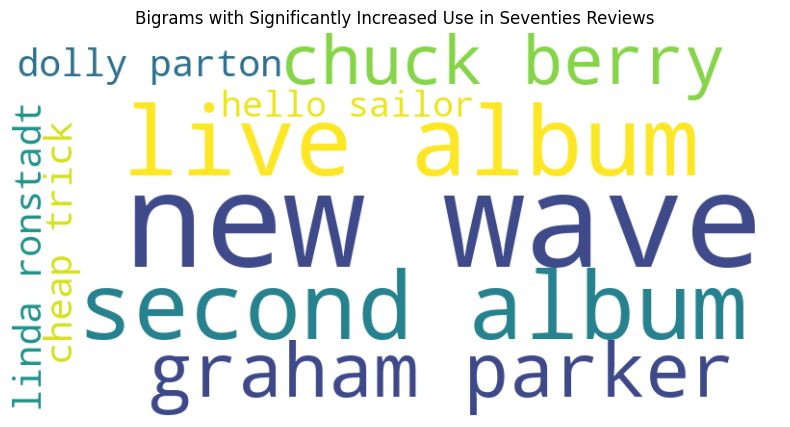

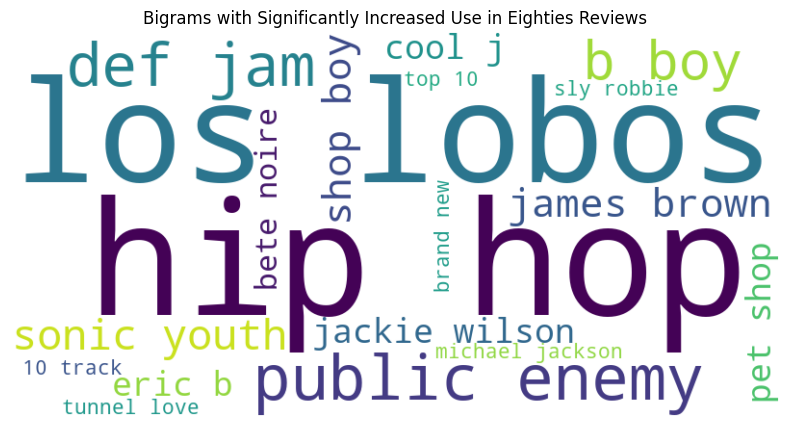

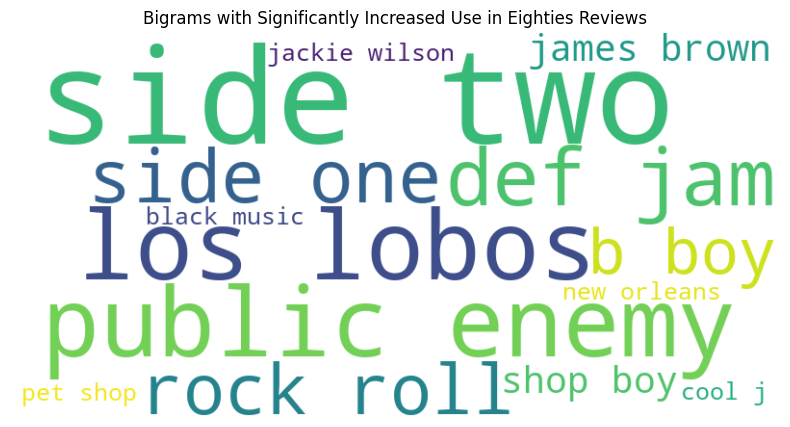

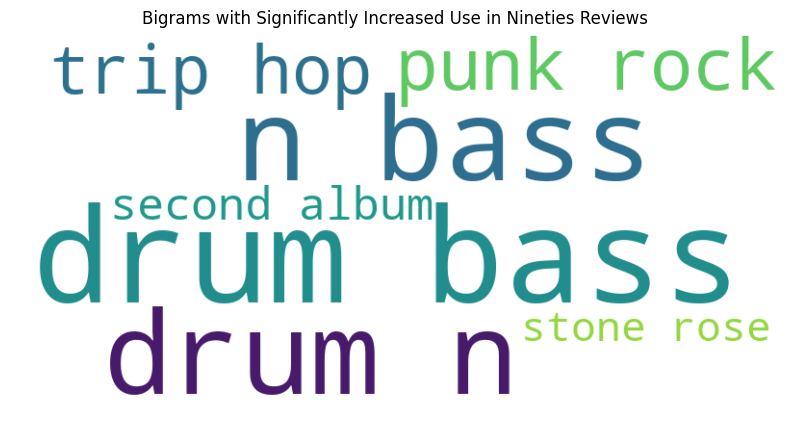

Bigram with significantly changed use by Log-Likelihood scores:
  hip hop: 55.90. From 0 to 36 appearances.
  rock roll: 39.44. From 32 to 0 appearances.
  drum bass: 36.94. From 2 to 32 appearances.
  n bass: 29.50. From 0 to 19 appearances.
  drum n: 29.50. From 0 to 19 appearances.
  side two: 27.12. From 22 to 0 appearances.
  trip hop: 23.29. From 0 to 15 appearances.
  side one: 22.74. From 24 to 1 appearances.
  new wave: 21.73. From 36 to 5 appearances.
Total of 9 bigrams with significantly changed use between 1970s and 1990s reviews.
Bigram with significantly changed use by Log-Likelihood scores:
  new wave: 32.52. From 36 to 0 appearances.
  hip hop: 22.27. From 0 to 11 appearances.
  los lobos: 20.24. From 0 to 10 appearances.
  public enemy: 20.24. From 0 to 10 appearances.
  def jam: 18.22. From 0 to 9 appearances.
  live album: 14.51. From 32 to 3 appearances.
  b boy: 14.17. From 0 to 7 appearances.
  sonic youth: 14.17. From 0 to 7 appearances.
  second album: 13.55. Fr

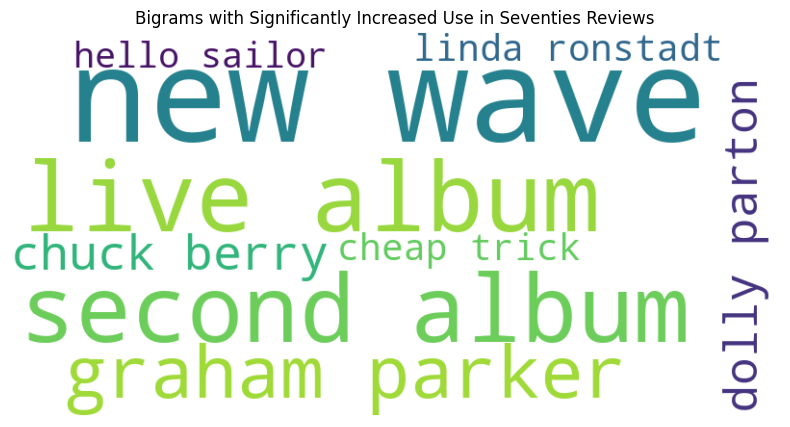

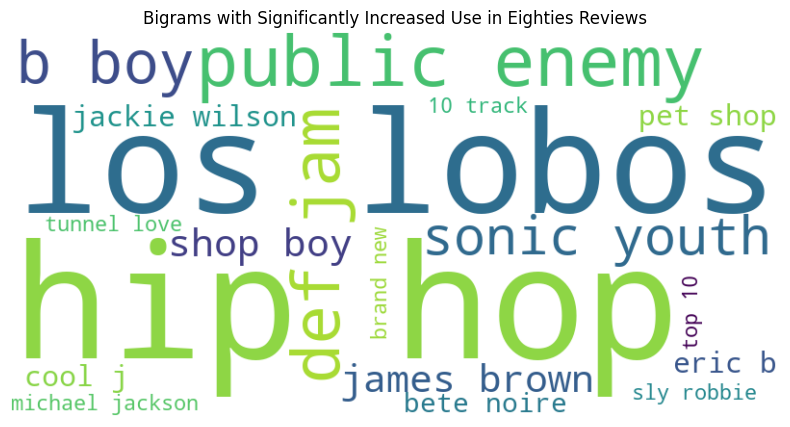

Bigram with significantly changed use by Log-Likelihood scores:
>  side two: 40.18. From 22 to 0 appearances.
<  drum bass: 25.69. From 1 to 32 appearances.
<  n bass: 19.49. From 0 to 19 appearances.
<  drum n: 19.49. From 0 to 19 appearances.
>  los lobos: 18.26. From 10 to 0 appearances.
>  public enemy: 18.26. From 10 to 0 appearances.
<  punk rock: 17.44. From 0 to 17 appearances.
>  def jam: 16.44. From 9 to 0 appearances.
<  trip hop: 15.39. From 0 to 15 appearances.
>  side one: 14.23. From 11 to 1 appearances.
>  rock roll: 12.78. From 7 to 0 appearances.
>  b boy: 12.78. From 7 to 0 appearances.
<  second album: 12.31. From 0 to 12 appearances.
>  james brown: 10.96. From 6 to 0 appearances.
>  shop boy: 10.96. From 6 to 0 appearances.
>  jackie wilson: 10.96. From 6 to 0 appearances.
>  cool j: 10.96. From 6 to 0 appearances.
>  new orleans: 10.96. From 6 to 0 appearances.
>  pet shop: 10.96. From 6 to 0 appearances.
>  black music: 10.96. From 6 to 0 appearances.
<  stone r

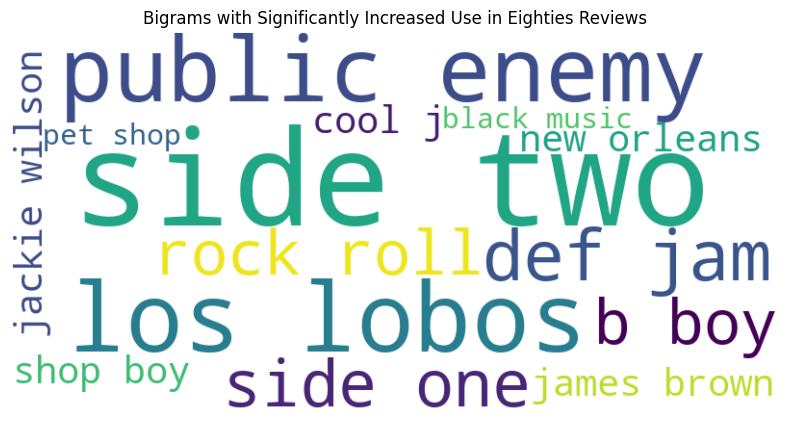

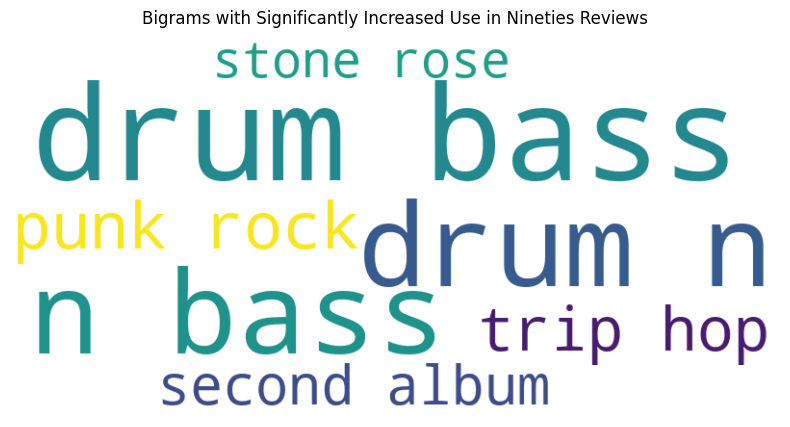

In [184]:
# CELL: Bigram Log Likelihood Analysis (using refactored functions)
# Using the common functions to analyze bigram frequency differences

# Use the refactored function for bigram analysis
bigram_results = analyze_decade_log_likelihoods(
    frequency_dicts=decade_bigram_frequencies,
    scrubbed_tokens_list=decade_scrubbed_tokens,
    analysis_type="bigrams",
    significance_thresholds={"7_9": 20, "7_8": 10, "8_9": 10}
)

# Extract results for compatibility with existing code
LLs_7_8 = bigram_results['LLs_7_8']
LLs_8_9 = bigram_results['LLs_8_9'] 
LLs_7_9 = bigram_results['LLs_7_9']
significantly_changed = bigram_results['significantly_changed']
increased_use_7_8 = bigram_results['increased_use_7_8']
increased_use_8_9 = bigram_results['increased_use_8_9']

# Draw wordclouds
draw_analysis_wordclouds(increased_use_7_8, increased_use_8_9, "bigrams")
sorted_LLs_7_8 = sorted(LLs_7_8.items(), key=lambda x: x[1], reverse=True)
sorted_LLs_8_9 = sorted(LLs_8_9.items(), key=lambda x: x[1], reverse=True)
sorted_LLs_7_9 = sorted(LLs_7_9.items(), key=lambda x: x[1], reverse=True)
print("Bigram with significantly changed use by Log-Likelihood scores:")
significance_threshold = 6.63  # p < 0.01
significance_threshold = 20
significantly_changed = set()
for word, score in sorted_LLs_7_9:
    if (score > significance_threshold): # LL scores greater than 6.63 are considered highly significant
        print(f"  {word}: {score:.2f}. From {decade_bigram_frequencies[Decade.Seventies.value][word]} to {decade_bigram_frequencies[Decade.Nineties.value][word]} appearances.")
        significantly_changed.add(word)
print(f"Total of {len(significantly_changed)} bigrams with significantly changed use between 1970s and 1990s reviews.")

significance_threshold = 10

print("Bigram with significantly changed use by Log-Likelihood scores:")
for word, score in sorted_LLs_7_8:
    if (score > significance_threshold): # LL scores greater than 6.63 are considered highly significant
        significantly_changed.add(word)
        print(f"  {word}: {score:.2f}. From {decade_bigram_frequencies[Decade.Seventies.value][word]} to {decade_bigram_frequencies[Decade.Eighties.value][word]} appearances.")
        if (decade_bigram_frequencies[Decade.Seventies.value][word] > decade_bigram_frequencies[Decade.Eighties.value][word]):
            increased_use_7_8[Decade.Seventies.value].append((word, score))
        else:
            increased_use_7_8[Decade.Eighties.value].append((word, score))
print(f"{len(increased_use_7_8[Decade.Seventies.value])} + {len(increased_use_7_8[Decade.Eighties.value])} Bigrams with significantly changed use between 1970s and 1980s reviews.")

for decade in [Decade.Seventies.value, Decade.Eighties.value]:
    bigram_freq_dist = FreqDist(dict(increased_use_7_8[decade]))

    draw_wordcloud(bigram_freq_dist, "Bigrams with Significantly Increased Use in " + Decade(decade).name + " Reviews")

print("Bigram with significantly changed use by Log-Likelihood scores:")
for word, score in sorted_LLs_8_9:
    if (score > significance_threshold): # LL scores greater than 6.63 are considered highly significant
        significantly_changed.add(word)
        if (decade_bigram_frequencies[Decade.Eighties.value][word] > decade_bigram_frequencies[Decade.Nineties.value][word]):
            print(f">  {word}: {score:.2f}. From {decade_bigram_frequencies[Decade.Eighties.value][word]} to {decade_bigram_frequencies[Decade.Nineties.value][word]} appearances.")
            increased_use_8_9[Decade.Eighties.value].append((word, score))
        else:
            print(f"<  {word}: {score:.2f}. From {decade_bigram_frequencies[Decade.Eighties.value][word]} to {decade_bigram_frequencies[Decade.Nineties.value][word]} appearances.")
            increased_use_8_9[Decade.Nineties.value].append((word, score))
print(f"{len(increased_use_8_9[Decade.Eighties.value])} + {len(increased_use_8_9[Decade.Nineties.value])} Bigrams with significantly changed use between 1980s and 1990s reviews.")

for decade in [Decade.Eighties.value, Decade.Nineties.value]:
    bigram_freq_dist = FreqDist(dict(increased_use_8_9[decade]))

    draw_wordcloud(bigram_freq_dist, "Bigrams with Significantly Increased Use in " + Decade(decade).name + " Reviews")



## get trigrams and their frequencies

In [191]:
from nltk import trigrams

decade_trigram_frequencies = [None] * len(Decade)

for decade in [Decade.Seventies.value, Decade.Eighties.value, Decade.Nineties.value]:
    tokens_for_trigrams = do_scrubbing(decade_review_tokens[decade], lemmatize=False)
    trigrams_list = list(trigrams(tokens_for_trigrams))
    # Convert trigrams to strings and create frequency distribution
    trigrams_as_strings = [f"{trigram[0]} {trigram[1]} {trigram[2]}" for trigram in trigrams_list]
    decade_trigram_frequencies[decade] = FreqDist(trigrams_as_strings)
    display(Markdown(f"Most common trigrams for decade {Decade(decade).name}:"))
    df = pd.DataFrame(decade_trigram_frequencies[decade].most_common(20), columns=['Word', 'Frequency'])
    display(df)

Initial token count: 99025
Final token count after scrubbing: 45397


Most common trigrams for decade Seventies:

,Word,Frequency
0,rock n roll,42
1,mink de ville,7
2,average white band,5
3,saturday night fever,5
4,greatest hits vol,4
5,rhythm n blues,4
6,juan reckless daughter,4
7,talking heads 77,4
8,day dog races,3
9,time loves hero,3


Initial token count: 56233
Final token count after scrubbing: 25922


Most common trigrams for decade Eighties:

,Word,Frequency
0,rock n roll,27
1,pet shop boys,6
2,bird nest roys,4
3,come long way,3
4,tour de force,3
5,black r b,3
6,ben e king,3
7,momentary lapse reason,3
8,eric b rakim,3
9,life one chord,3


Initial token count: 83166
Final token count after scrubbing: 38679


Most common trigrams for decade Nineties:

,Word,Frequency
0,rock n roll,36
1,drum n bass,19
2,dark dear heart,5
3,voodoo glow skulls,4
4,jonathan fire eater,4
5,ten foot pole,3
6,blue sky mars,3
7,first solo album,3
8,breaks co op,3
9,ocean colour scene,3


Trigrams with significantly changed use by Log-Likelihood scores:
  drum n bass: 29.80. From 0 to 19 appearances.
  mink de ville: 8.54. From 7 to 0 appearances.
  dark dear heart: 7.84. From 0 to 5 appearances.
  jonathan fire eater: 6.27. From 0 to 4 appearances.
  voodoo glow skulls: 6.27. From 0 to 4 appearances.
  saturday night fever: 6.10. From 5 to 0 appearances.
  rhythm n blues: 4.88. From 4 to 0 appearances.
  talking heads 77: 4.88. From 4 to 0 appearances.
  greatest hits vol: 4.88. From 4 to 0 appearances.
  juan reckless daughter: 4.88. From 4 to 0 appearances.
  self titled debut: 4.71. From 0 to 3 appearances.
  dance hall crashers: 4.71. From 0 to 3 appearances.
  touch runs wild: 4.71. From 0 to 3 appearances.
  ten foot pole: 4.71. From 0 to 3 appearances.
  plastic ono band: 4.71. From 0 to 3 appearances.
  new zealand dance: 4.71. From 0 to 3 appearances.
  everything touch runs: 4.71. From 0 to 3 appearances.
  yeah yeah yeah: 4.71. From 0 to 3 appearances.
  sim

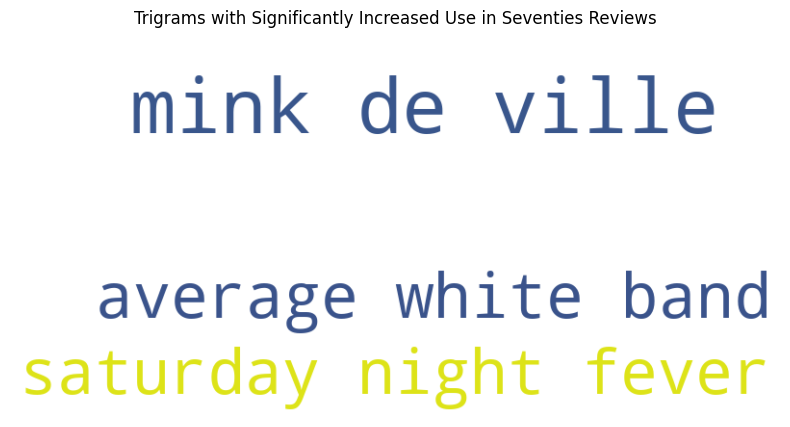

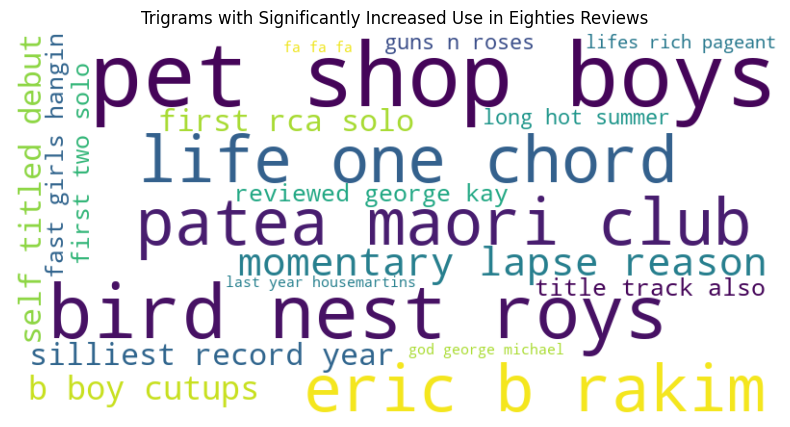

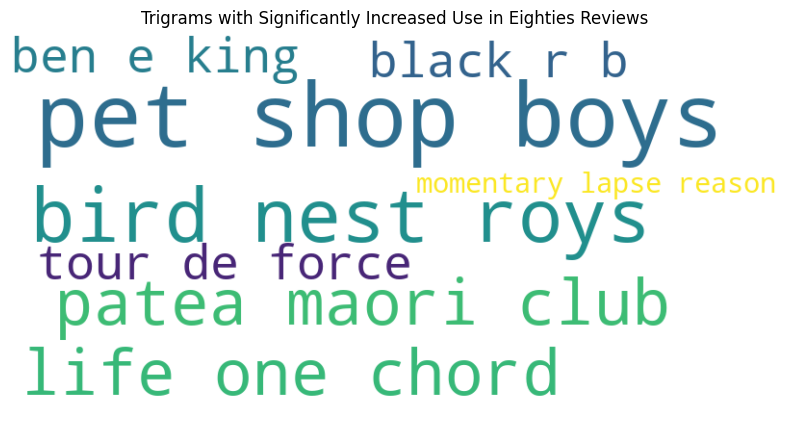

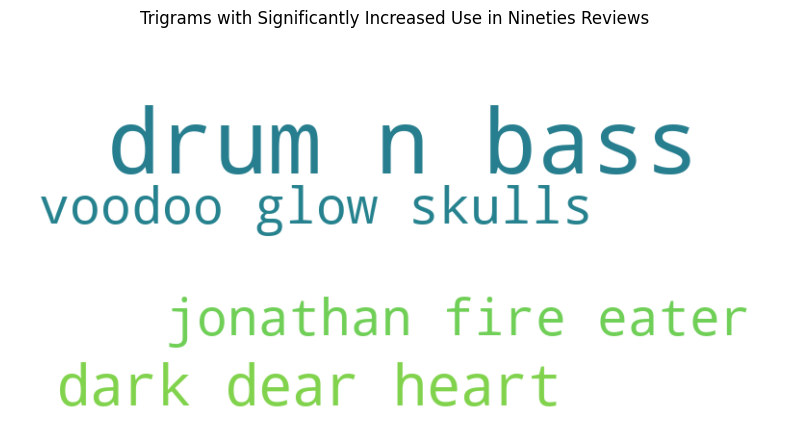

In [193]:
# Analyze trigram frequency changes
trigram_results = analyze_decade_log_likelihoods(
    frequency_dicts=decade_trigram_frequencies,
    scrubbed_tokens_list=decade_review_tokens,
    analysis_type="trigrams",
    significance_thresholds={"7_9": 4, "7_8": 4, "8_9": 4}
)

# Draw wordclouds for significantly changed trigrams
draw_analysis_wordclouds(
    trigram_results['increased_use_7_8'], 
    trigram_results['increased_use_8_9'], 
    analysis_type="trigrams"
)